<div align="center">
    <img src="https://www.sharif.ir/documents/20124/0/logo-fa-IR.png/4d9b72bc-494b-ed5a-d3bb-e7dfd319aec8?t=1609608338755" alt="Logo" width="200">
    <p><b>HW2 @ Deep Learning Course, Dr. Soleymani</b></p>
    <p><b>Desinged by Mohammad Amanlou</b></p>
</div>

---




*Full Name:* Faraz Doagooye Tehrani

*Student Number:* 402105998

# تمرین CNN — «آزمایشگاه حال‌سنجی ایموجی‌ها»
## نسخه‌ی پاسخ‌دار برای طراح تمرین

در این پروژه قرار است یک **CNN از صفر** برای تشخیص حالت چهره‌ی ایموجی‌ها بسازیم.  
ایده‌ی پروژه این است که یک ربات بامزه باید از روی تصویر ایموجی‌ها تشخیص بدهد که حال آن‌ها چیست:

- `happy`
- `sad`
- `angry`
- `surprised`
- `sleepy`

## داستان پروژه
در شهر ایموجی‌ها، یک ربات کوچک وظیفه دارد پیام‌های تصویری را مرتب‌سازی کند.  
اما ایموجی‌ها همیشه تمیز و واضح نیستند: گاهی کمی چرخیده‌اند، گاهی نویز دارند، گاهی جابه‌جا شده‌اند.  
هدف شما این است که یک مدل CNN طراحی کنید که در چنین شرایطی هم بتواند حالت چهره را درست تشخیص دهد.

## بعد از انجام این نوت‌بوک باید بتوانید:
1. یک دیتاست تصویری را بسازید یا بارگذاری کنید.
2. روی داده‌ها **EDA** ساده انجام دهید.
3. **Data Augmentation** مناسب برای مسئله‌ی تصویری انتخاب کنید.
4. یک **CNN پایه** را از صفر پیاده‌سازی و آموزش دهید.
5. با استفاده از **loss curve**، **accuracy**، **macro F1** و **confusion matrix** مدل را تحلیل کنید.
6. خطاهای مدل را بررسی کنید و یک نسخه‌ی بهبود‌یافته از مدل ارائه دهید.

## بخش ۰ — کتابخانه‌ها و تنظیمات اولیه

### خروجی مورد انتظار
- چاپ دستگاه اجرا
- چاپ نام کلاس‌ها

In [24]:
import math
import random
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image, ImageDraw, ImageFilter, ImageOps, ImageEnhance
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

IMG_SIZE = 64
BATCH_SIZE = 64
NUM_CLASSES = 7
CLASS_NAMES = ["happy", "sad", "angry", "surprised", "sleepy", "cool", "confused"]

print('device:' + device.type)
print('class names:')
print(CLASS_NAMES)

device:mps
class names:
['happy', 'sad', 'angry', 'surprised', 'sleepy', 'cool', 'confused']


## بخش ۱ — ساخت دیتاست مصنوعی ایموجی‌ها

In [25]:
def _jitter(rng, low, high):
    return rng.randint(low, high)

def add_soft_noise(img, rng, amount=35):
    arr = np.array(img).astype(np.int16)
    noise = rng.normalvariate(0, 1)
    gaussian = np.random.default_rng(rng.randint(0, 10_000)).normal(0, amount, size=arr.shape)
    arr = np.clip(arr + gaussian, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

def draw_emoji(label, img_size=64, seed=0, hard_mode=False):
    rng = random.Random(seed)

    bg_color = (
        245 + _jitter(rng, -8, 8),
        245 + _jitter(rng, -8, 8),
        250 + _jitter(rng, -8, 5),
    )
    img = Image.new("RGB", (img_size, img_size), bg_color)
    draw = ImageDraw.Draw(img)

    # background dots
    for _ in range(40 if not hard_mode else 70):
        x = _jitter(rng, 0, img_size - 1)
        y = _jitter(rng, 0, img_size - 1)
        r = _jitter(rng, 1, 2)
        c = 235 + _jitter(rng, -18, 12)
        draw.ellipse((x-r, y-r, x+r, y+r), fill=(c, c, c + _jitter(rng, -5, 5)))

    cx = img_size // 2 + _jitter(rng, -3, 3)
    cy = img_size // 2 + _jitter(rng, -3, 3)
    radius = 22 + _jitter(rng, -2, 2)

    draw.ellipse(
        (cx - radius, cy - radius, cx + radius, cy + radius),
        fill=(252, 215 + _jitter(rng, -12, 8), 70 + _jitter(rng, -10, 8)),
        outline=(120, 90, 20),
        width=2,
    )

    if rng.random() < 0.55:
        cheek_color = (245, 165 + _jitter(rng, -10, 10), 165 + _jitter(rng, -10, 10))
        draw.ellipse((cx - 16, cy + 2, cx - 10, cy + 8), fill=cheek_color)
        draw.ellipse((cx + 10, cy + 2, cx + 16, cy + 8), fill=cheek_color)

    ex = 9 + _jitter(rng, -1, 1)
    ey = 8 + _jitter(rng, -1, 1)

    left_eye = (cx - ex, cy - ey)
    right_eye = (cx + ex, cy - ey)

    def draw_open_eye(center, w=4, h=5):
        x, y = center
        draw.ellipse((x - w//2, y - h//2, x + w//2, y + h//2), fill=(20, 20, 20))

    def draw_closed_eye(center, width=6):
        x, y = center
        draw.line((x - width//2, y, x + width//2, y), fill=(20, 20, 20), width=2)

    def draw_arc_eye(center, start, end, width=2):
        x, y = center
        box = (x - 4, y - 4, x + 4, y + 4)
        draw.arc(box, start=start, end=end, fill=(20, 20, 20), width=width)

    if label == "sad":
        draw.line((left_eye[0] - 5, left_eye[1] - 6, left_eye[0] + 2, left_eye[1] - 8), fill=(80, 40, 10), width=2)
        draw.line((right_eye[0] - 2, right_eye[1] - 8, right_eye[0] + 5, right_eye[1] - 6), fill=(80, 40, 10), width=2)
    elif label == "angry":
        draw.line((left_eye[0] - 5, left_eye[1] - 8, left_eye[0] + 2, left_eye[1] - 6), fill=(80, 40, 10), width=2)
        draw.line((right_eye[0] - 2, right_eye[1] - 6, right_eye[0] + 5, right_eye[1] - 8), fill=(80, 40, 10), width=2)
    elif label == "surprised":
        draw.line((left_eye[0] - 4, left_eye[1] - 8, left_eye[0] + 4, left_eye[1] - 8), fill=(90, 50, 10), width=2)
        draw.line((right_eye[0] - 4, right_eye[1] - 8, right_eye[0] + 4, right_eye[1] - 8), fill=(90, 50, 10), width=2)
    elif label == "confused":
        draw.line((left_eye[0] - 5, left_eye[1] - 9, left_eye[0] + 3, left_eye[1] - 6), fill=(80, 40, 10), width=2)
        draw.line((right_eye[0] - 3, right_eye[1] - 5, right_eye[0] + 5, right_eye[1] - 5), fill=(80, 40, 10), width=2)
    elif label == "cool":
        glass_w, glass_h = 13, 9
        draw.ellipse((left_eye[0]-glass_w//2, left_eye[1]-glass_h//2, left_eye[0]+glass_w//2, left_eye[1]+glass_h//2), fill=(15, 15, 15))
        draw.ellipse((right_eye[0]-glass_w//2, right_eye[1]-glass_h//2, right_eye[0]+glass_w//2, right_eye[1]+glass_h//2), fill=(15, 15, 15))
        draw.line((left_eye[0], left_eye[1] - 1, right_eye[0], right_eye[1] - 1), fill=(15, 15, 15), width=3)
        draw.line((left_eye[0]-glass_w//2, left_eye[1]-1, cx-radius, cy-4), fill=(15, 15, 15), width=2)
        draw.line((right_eye[0]+glass_w//2, right_eye[1]-1, cx+radius, cy-4), fill=(15, 15, 15), width=2)

    if label == "happy":
        draw_arc_eye(left_eye, 10, 170, width=2)
        draw_arc_eye(right_eye, 10, 170, width=2)
        draw.arc((cx - 11, cy - 1, cx + 11, cy + 15), start=15, end=165, fill=(120, 30, 30), width=3)

    elif label == "sad":
        draw_open_eye(left_eye, 3, 5)
        draw_open_eye(right_eye, 3, 5)
        draw.arc((cx - 11, cy + 8, cx + 11, cy + 20), start=200, end=340, fill=(120, 30, 30), width=3)
        if rng.random() < 0.65:
            # a tear
            tx = left_eye[0] - 2
            ty = left_eye[1] + 6
            draw.ellipse((tx - 2, ty, tx + 2, ty + 6), fill=(100, 180, 255))

    elif label == "angry":
        draw_open_eye(left_eye, 3, 5)
        draw_open_eye(right_eye, 3, 5)
        draw.arc((cx - 10, cy + 7, cx + 10, cy + 19), start=200, end=340, fill=(120, 10, 10), width=3)

    elif label == "surprised":
        draw_open_eye(left_eye, 4, 6)
        draw_open_eye(right_eye, 4, 6)
        mouth_r = 5 + _jitter(rng, -1, 1)
        draw.ellipse((cx - mouth_r, cy + 6, cx + mouth_r, cy + 6 + 2*mouth_r), outline=(120, 30, 30), width=3)

    elif label == "sleepy":
        draw_closed_eye(left_eye, width=7)
        draw_closed_eye(right_eye, width=7)
        draw.arc((cx - 10, cy + 6, cx + 10, cy + 12), start=5, end=175, fill=(120, 30, 30), width=2)
        if rng.random() < 0.5:
            bx = right_eye[0] + 5
            by = right_eye[1] - 2
            draw.ellipse((bx, by, bx + 5, by + 5), outline=(120, 180, 255), width=2)

    elif label == "cool":
        draw.arc((cx - 6, cy + 3, cx + 12, cy + 13), start=20, end=160, fill=(100, 20, 20), width=3)

    elif label == "confused":
        draw_open_eye(left_eye, w=6, h=6)
        draw_open_eye(right_eye, w=3, h=3)
        mx_left, my_left = cx - 9, cy + 11 + _jitter(rng, -1, 1)
        mx_right, my_right = cx + 9, cy + 7 + _jitter(rng, -1, 1)
        draw.line((mx_left, my_left, mx_right, my_right), fill=(120, 30, 30), width=3)

    if hard_mode and rng.random() < 0.45:
        y0 = cy + _jitter(rng, -3, 6)
        draw.rectangle((cx - 14, y0, cx + 14, y0 + 3), fill=(230, 230, 230))

    img = img.rotate(_jitter(rng, -10, 10) if not hard_mode else _jitter(rng, -18, 18), fillcolor=bg_color)

    if rng.random() < (0.4 if not hard_mode else 0.75):
        img = add_soft_noise(img, rng, amount=14 if not hard_mode else 24)

    if hard_mode and rng.random() < 0.3:
        img = img.filter(ImageFilter.GaussianBlur(radius=0.7))

    return img

## بخش ۲ — مشاهده‌ی نمونه‌ها و بررسی اولیه‌ی داده

### صورت سؤال
1. از هر کلاس چند نمونه تصویر نمایش دهید.
2. درباره‌ی تفاوت‌های ظاهری کلاس‌ها توضیح کوتاه بنویسید.
3. تعداد نمونه‌های هر کلاس در هر split را مشخص کنید.
4. یک نمودار میله‌ای از توزیع داده‌ها رسم کنید.

### خروجی مورد انتظار
- یک grid از نمونه‌تصاویر
- جدول یا نمودار تعداد نمونه‌ها

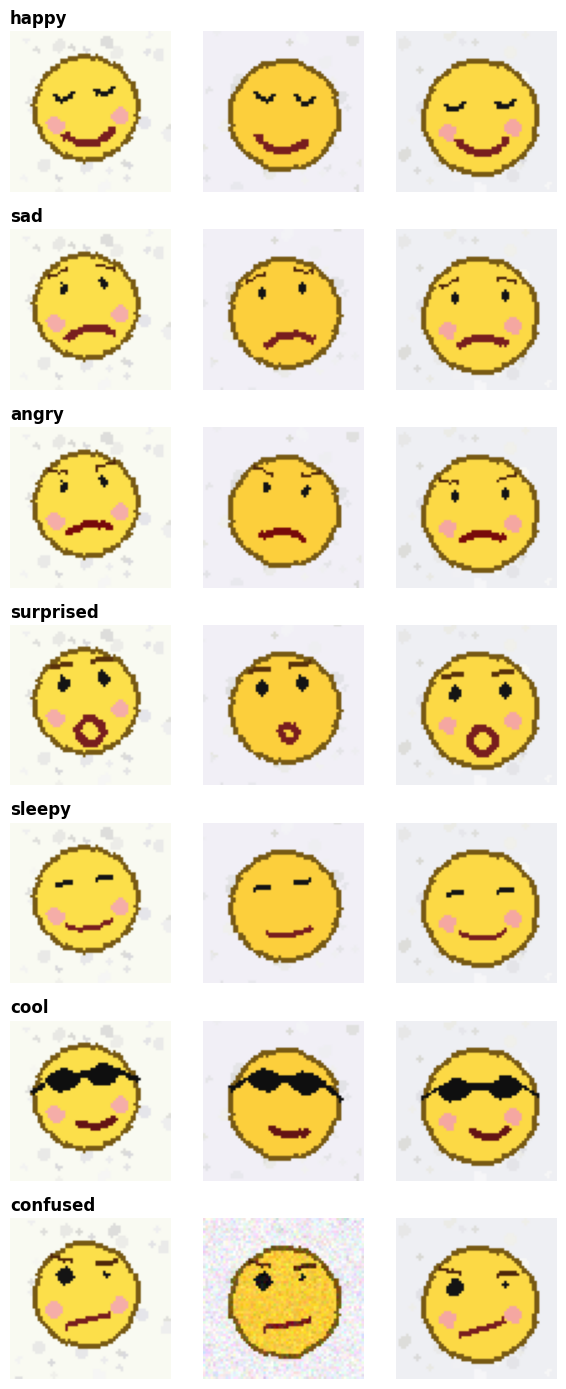

In [26]:
def show_samples_per_class(class_names, samples_per_class=3, hard_mode=False):
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(samples_per_class * 2, len(class_names) * 2))
    
    for row_idx, class_name in enumerate(class_names):
        for col_idx in range(samples_per_class):
            img = draw_emoji(class_name, seed=col_idx, hard_mode=hard_mode)
            ax = axes[row_idx, col_idx]
            ax.imshow(img)
            ax.axis("off")
            
            if col_idx == 0:
                ax.set_title(class_name, loc='left', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

show_samples_per_class(CLASS_NAMES, samples_per_class=3)

The mouths and the eyes and eyebrows are the main difference between the classes and the similiarity in between the images of the same class.

,split,label_name,label_idx,seed,hard_mode
0,train,sleepy,4,40062,False
1,train,sad,1,10115,False
2,train,sleepy,4,40082,False
3,train,surprised,3,30169,False
4,train,angry,2,20039,False


,split,label_name,count
0,test,angry,100
1,test,confused,100
2,test,cool,100
3,test,happy,100
4,test,sad,100
5,test,sleepy,100
6,test,surprised,100
7,train,angry,300
8,train,confused,300
9,train,cool,300


Text(0, 0.5, 'Count')

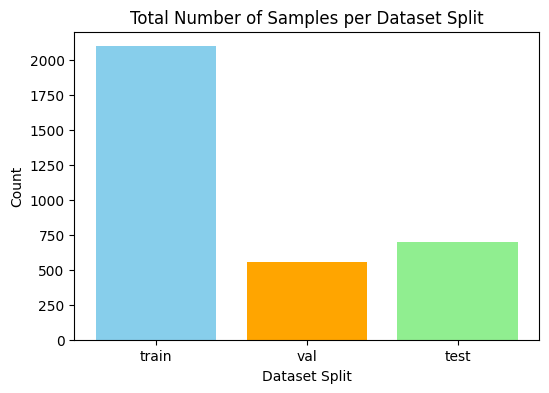

In [27]:
SPLIT_COUNTS = {
    "train": 300,
    "val": 80,
    "test": 100,
}

def build_records(split_name, class_names, counts_per_class, hard_mode=False, seed_offset=0):
    records = []
    label_to_idx = {name: i for i, name in enumerate(class_names)}
    for class_name in class_names:
        label_idx = label_to_idx[class_name]
        for i in range(counts_per_class):
            records.append({
                "split": split_name,
                "label_name": class_name,
                "label_idx": label_idx,
                "seed": seed_offset + 10_000 * label_idx + i,
                "hard_mode": hard_mode,
            })
    random.Random(SEED + seed_offset).shuffle(records)
    return records

train_records = build_records('train', CLASS_NAMES, SPLIT_COUNTS["train"])
val_records   = build_records('val', CLASS_NAMES, SPLIT_COUNTS["val"])
test_records  = build_records('test', CLASS_NAMES, SPLIT_COUNTS["test"])

all_records = pd.DataFrame(train_records + val_records + test_records)
display(all_records.head())

count_df = all_records.groupby(["split", "label_name"]).size().reset_index(name="count")
display(count_df)

counts = all_records['split'].value_counts().reindex(['train', 'val', 'test'])

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color=['skyblue', 'orange', 'lightgreen'])

plt.title("Total Number of Samples per Dataset Split")
plt.xlabel("Dataset Split")
plt.ylabel("Count")


## بخش ۳ — پیش‌پردازش و Data Augmentation

### صورت سؤال
1. برای داده‌های آموزشی یک pipeline مناسب از augmentation تعریف کنید.
2. برای داده‌های اعتبارسنجی و تست فقط پیش‌پردازش‌های ضروری را اعمال کنید.
3. توضیح دهید چرا در این مسئله این تبدیلات مناسب‌اند.

### پیشنهاد
برای train می‌توانید از موارد زیر استفاده کنید:
- `RandomRotation`
- `RandomResizedCrop`
- `ColorJitter`
- `RandomHorizontalFlip`

### خروجی مورد انتظار
- تعریف transformهای train / val / test
- نمایش یک نمونه تصویر قبل و بعد از augmentation

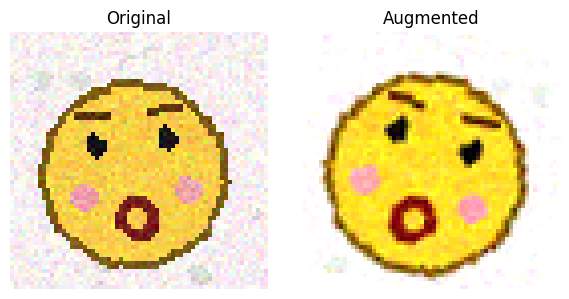

In [28]:
class Compose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img):
        for transform in self.transforms:
            img = transform(img)
        return img

class Resize:
    def __init__(self, size):
        if isinstance(size, int):
            size = (size, size)
        self.size = size

    def __call__(self, img):
        return img.resize(self.size)

class RandomHorizontalFlip:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, img):
        rand = random.random()
        return_img = img
        if rand <= self.p:
            return_img = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        return return_img

class RandomRotation:
    def __init__(self, degrees):
        self.degrees = degrees

    def __call__(self, img):
        random_angle = random.randint(-1 * self.degrees, self.degrees)
        rotated_img = img.rotate(random_angle, resample=Image.Resampling.BILINEAR, fillcolor=(245, 245, 250))
        return rotated_img


class RandomResizedCrop:
    def __init__(self, size, scale=(0.85, 1.0)):
        self.size = (size, size) if isinstance(size, int) else size
        self.scale = scale

    def __call__(self, img):
        width, height = img.size
        scale_factor = random.uniform(self.scale[0], self.scale[1])
        crop_w = int(width * scale_factor)
        crop_h = int(height * scale_factor)
        
        max_x = width - crop_w
        max_y = height - crop_h
        
        left = random.randint(0, max_x) if max_x > 0 else 0
        upper = random.randint(0, max_y) if max_y > 0 else 0
        
        right = left + crop_w
        lower = upper + crop_h
        
        cropped_img = img.crop((left, upper, right, lower))
        
        return cropped_img.resize(self.size, resample=Image.Resampling.LANCZOS)

class ColorJitter:
    def __init__(self, brightness=0.0, contrast=0.0, saturation=0.0):
        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation

    def __call__(self, img):
        if self.brightness > 0:
            factor = random.uniform(max(0.0, 1.0 - self.brightness), 1.0 + self.brightness)
            img = ImageEnhance.Brightness(img).enhance(factor)
            
        if self.contrast > 0:
            factor = random.uniform(max(0.0, 1.0 - self.contrast), 1.0 + self.contrast)
            img = ImageEnhance.Contrast(img).enhance(factor)
            
        if self.saturation > 0:
            factor = random.uniform(max(0.0, 1.0 - self.saturation), 1.0 + self.saturation)
            img = ImageEnhance.Color(img).enhance(factor)
        return img

class ToTensorNormalize:
    def __init__(self, mean, std):
        self.mean = np.array(mean, dtype=np.float32).reshape(3, 1, 1)
        self.std = np.array(std, dtype=np.float32).reshape(3, 1, 1)

    def __call__(self, img):
        if img.mode != "RGB":
            img = img.convert("RGB")
        arr = np.array(img, dtype=np.float32)
        arr /= 255.0
        tensor = arr.transpose(2, 0, 1)
        normalized_tensor = (tensor - self.mean) / self.std
        return torch.from_numpy(normalized_tensor)


MEAN = [0.5, 0.5, 0.5]
STD  = [0.5, 0.5, 0.5]

train_transform = Compose([
    RandomResizedCrop(size=IMG_SIZE),
    RandomHorizontalFlip(),
    RandomRotation(degrees=15),
    ColorJitter(0.2, 0.2, 0.2),
    ToTensorNormalize(mean=MEAN, std=STD)
])

eval_transform = Compose([
    Resize(size=IMG_SIZE),
    ToTensorNormalize(mean=MEAN, std=STD)    
])

def denormalize(t):
    t = t.detach().cpu()
    img = (t * 0.5) + 0.5
    
    img = torch.clamp(img, 0.0, 1.0)
    
    img = img.permute(1, 2, 0)
    
    return (img.numpy() * 255).astype(np.uint8)

sample_img = draw_emoji("surprised", img_size=IMG_SIZE, seed=1234)
augmented = train_transform(sample_img)
augmented_vis = denormalize(augmented)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(sample_img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(augmented_vis)
axes[1].set_title("Augmented")
axes[1].axis("off")
            
plt.tight_layout()
plt.show()

## بخش ۴ — ساخت Dataset و DataLoader

### صورت سؤال
1. برای train / val / test سه DataLoader ایجاد کنید.
2. یک batch را نمایش دهید و shape داده‌ها و برچسب‌ها را چاپ کنید.

### خروجی مورد انتظار
- سه dataloader
- نمایش یک batch نمونه

In [29]:
class EmojiMoodDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = draw_emoji(
            rec["label_name"],
            img_size=IMG_SIZE,
            seed=rec["seed"],
            hard_mode=rec["hard_mode"],
        )
        if self.transform is not None:
            img = self.transform(img)
        label = rec["label_idx"]
        return img, label

train_dataset = EmojiMoodDataset(records=train_records, transform=train_transform)
val_dataset   = EmojiMoodDataset(records=val_records, transform=eval_transform)
test_dataset  = EmojiMoodDataset(records=test_records, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([64, 3, 64, 64])
Batch label shape: torch.Size([64])


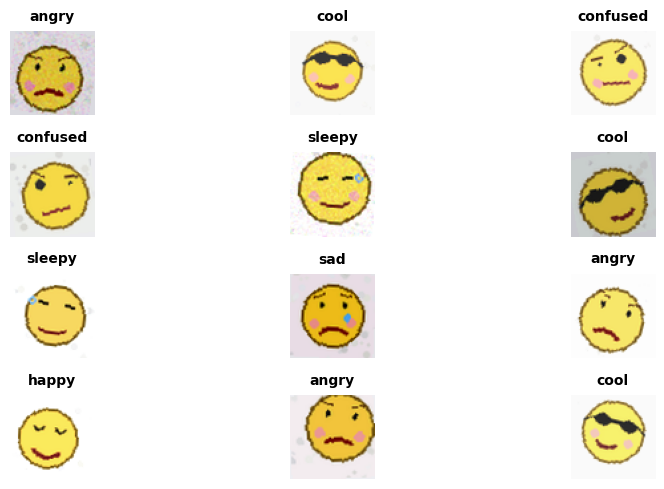

In [30]:
def show_batch(images, labels, class_names, max_items=12):
    fig, axes = plt.subplots(int(max_items / 3), 3, figsize=(10, 5))
    axes = axes.flatten()

    idx_to_label = {i: name for i, name in enumerate(class_names)}


    for i in range(max_items):
        img = denormalize(images[i])
        label_idx = labels[i].item()
        label_text = idx_to_label.get(label_idx, f"Class {label_idx}")
        
        axes[i].imshow(img)
        
        axes[i].set_title(label_text, fontsize=10, fontweight="bold", pad=8)
        
        axes[i].axis("off")
        

    plt.tight_layout()
    plt.show()

show_batch(images, labels, CLASS_NAMES)

## بخش ۵ — طراحی CNN پایه

### صورت سؤال
یک CNN پایه از صفر طراحی کنید که:
1. حداقل 3 بلوک کانولوشنی داشته باشد.
2. در انتها برای طبقه‌بندی از fully connected layers استفاده کند.
3. برای جلوگیری از overfitting از dropout استفاده کند.

### کارهای لازم
- مدل را پیاده‌سازی کنید.
- summary ساده‌ای از تعداد پارامترها گزارش کنید.
- یک forward pass آزمایشی انجام دهید.

### خروجی مورد انتظار
- تعریف مدل
- تعداد پارامترهای قابل آموزش
- shape خروجی مدل برای یک batch نمونه

In [31]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
            )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) 
        )
        
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5), 
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.fc(x)

        return x

baseline_model = BaselineCNN()

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(baseline_model)
print(f"Trainable params: {count_trainable_params(baseline_model):,}")

output = baseline_model(images)

print(f"Output Shape: {output.shape}")

BaselineCNN(
  (block1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Sequential(
    (0): Linear(in_features=4096, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=7, bias=True)
  )
)
Trainable params: 1,074,215
Output Shape: torch.Size([64, 7])


## بخش ۶ — توابع آموزش و ارزیابی

### صورت سؤال
توابع زیر را پیاده‌سازی کنید:
1. `train_one_epoch`
2. `evaluate_one_epoch`
3. یک حلقه‌ی آموزشی کامل که:
   - loss و accuracy را ذخیره کند
   - بهترین مدل را بر اساس validation loss نگه دارد

### نکته
در این تمرین از:
- `CrossEntropyLoss`
- بهینه‌ساز `Adam`

استفاده می‌کنیم.

### خروجی مورد انتظار
- توابع عمومی آموزش و ارزیابی

In [32]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_preds += torch.sum(preds == labels).item()
        total_samples += images.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_preds / total_samples
    
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_preds += torch.sum(preds == labels).item()
        total_samples += images.size(0)
    
    

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_preds / total_samples
    
    return epoch_loss, epoch_acc

def fit_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=8,
    patience=3,
    scheduler=None
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_state = deepcopy(model.state_dict())
    best_val_loss = float("inf")
    wait = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_one_epoch(model, val_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        
        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    return history

## بخش ۷ — آموزش مدل پایه

### صورت سؤال
1. criterion و optimizer را تعریف کنید.
2. مدل پایه را برای چند epoch آموزش دهید.
3. تاریخچه‌ی آموزش را ذخیره کنید.
4. در پایان، بهترین نسخه‌ی مدل را نگه دارید.

### خروجی مورد انتظار
- لاگ آموزش در هر epoch

In [33]:
baseline_model = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

baseline_history = fit_model(baseline_model, train_loader, val_loader, criterion, optimizer, device)

Epoch 01 | train_loss=1.5042 train_acc=0.3892 | val_loss=0.5815 val_acc=0.8184
Epoch 02 | train_loss=0.6602 train_acc=0.7515 | val_loss=0.2696 val_acc=0.9375
Epoch 03 | train_loss=0.4278 train_acc=0.8237 | val_loss=0.2000 val_acc=0.8730
Epoch 04 | train_loss=0.3379 train_acc=0.8540 | val_loss=0.1631 val_acc=0.9238
Epoch 05 | train_loss=0.2683 train_acc=0.8828 | val_loss=0.1514 val_acc=0.9258
Epoch 06 | train_loss=0.2288 train_acc=0.9053 | val_loss=0.1118 val_acc=0.9883
Epoch 07 | train_loss=0.1888 train_acc=0.9170 | val_loss=0.1300 val_acc=0.9219
Epoch 08 | train_loss=0.1773 train_acc=0.9272 | val_loss=0.0947 val_acc=0.9785


## بخش ۸ — رسم نمودارهای آموزش

### صورت سؤال
1. نمودار `train/val loss` را رسم کنید.
2. نمودار `train/val accuracy` را رسم کنید.
3. توضیح دهید آیا نشانه‌ای از overfitting یا underfitting مشاهده می‌شود یا خیر.

### خروجی مورد انتظار
- دو نمودار

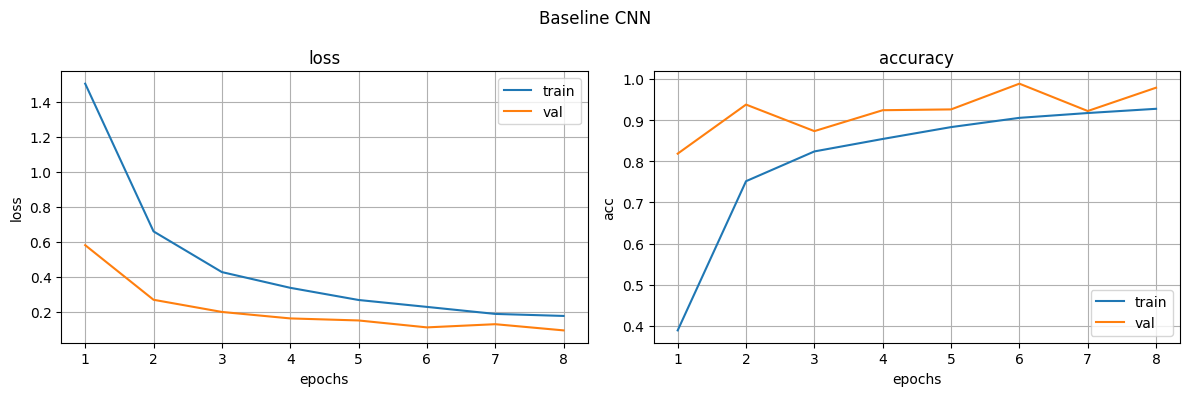

In [34]:
def plot_history(history, title_prefix="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history['train_loss'], label='train')
    axes[0].plot(epochs, history['val_loss'], label='val') 
    axes[0].set_title("loss")          
    axes[0].legend()
    axes[0].grid()
    axes[0].set_xlabel('epochs')
    axes[0].set_ylabel('loss')

    axes[1].plot(epochs, history['train_acc'], label='train')
    axes[1].plot(epochs, history['val_acc'], label='val') 
    axes[1].set_title("accuracy")           
    axes[1].legend()
    axes[1].grid()
    axes[1].set_xlabel('epochs')
    axes[1].set_ylabel('acc')

    fig.suptitle(title_prefix)
    plt.tight_layout()
    plt.show()

plot_history(baseline_history, title_prefix="Baseline CNN")

No real sign of overfitting in these epochs but maybe the model can do a better job if it is made more complex

## بخش ۹ — ارزیابی نهایی روی داده‌ی تست

### صورت سؤال
1. مدل را روی test set ارزیابی کنید.
2. معیارهای زیر را گزارش کنید:
   - Accuracy
   - Precision (macro)
   - Recall (macro)
   - F1-score (macro)
3. یک **Confusion Matrix** رسم کنید.
4. نتیجه را تفسیر کنید: کدام کلاس‌ها بیشتر با هم اشتباه می‌شوند؟

### خروجی مورد انتظار
- metricها
- confusion matrix
- classification report

Baseline Test Accuracy : 0.9828
Baseline Test Precision: 0.9832
Baseline Test Recall   : 0.9822
Baseline Test F1-score : 0.9823

Classification report:
              precision    recall  f1-score   support

       happy       1.00      1.00      1.00        94
         sad       0.98      0.90      0.93        88
       angry       0.91      0.98      0.94        90
   surprised       1.00      1.00      1.00        85
      sleepy       1.00      1.00      1.00        93
        cool       1.00      1.00      1.00        94
    confused       1.00      1.00      1.00        96

    accuracy                           0.98       640
   macro avg       0.98      0.98      0.98       640
weighted avg       0.98      0.98      0.98       640



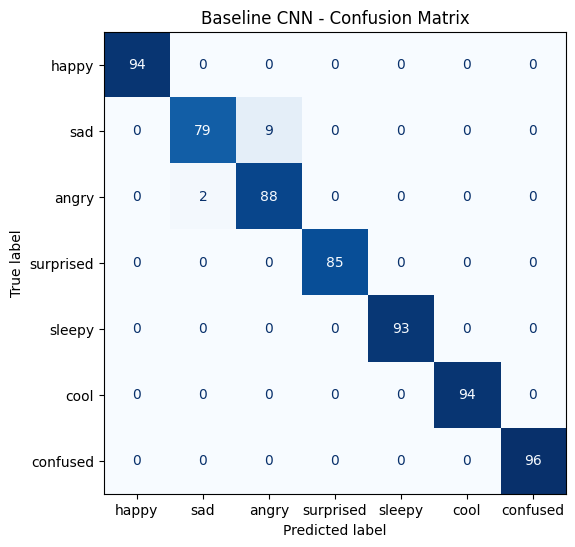

In [35]:
@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    all_probs, all_preds, all_targets = [], [], []

    for images, targets in loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_targets.append(targets)

    all_probs = torch.cat(all_probs).numpy()
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    return all_probs, all_preds, all_targets

baseline_probs, baseline_preds, test_targets = predict_loader(baseline_model, test_loader, device)

baseline_acc = accuracy_score(test_targets, baseline_preds)
baseline_prec, baseline_rec, baseline_f1, _ = precision_recall_fscore_support(test_targets, baseline_preds, average='macro')

print(f"Baseline Test Accuracy : {baseline_acc:.4f}")
print(f"Baseline Test Precision: {baseline_prec:.4f}")
print(f"Baseline Test Recall   : {baseline_rec:.4f}")
print(f"Baseline Test F1-score : {baseline_f1:.4f}")

print("\nClassification report:")
report = classification_report(test_targets, baseline_preds, target_names=CLASS_NAMES)
print(report)

cm = confusion_matrix(test_targets, baseline_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Baseline CNN - Confusion Matrix")
plt.show()

Sad and Angry classes are somtiems mistaken for one another and also happy and sleppy(not in this instance)

## بخش ۱۰ — تحلیل خطاها

### صورت سؤال
1. چند نمونه از تصاویر اشتباه‌طبقه‌بندی‌شده را نمایش دهید.
2. برای هر نمونه، برچسب واقعی و برچسب پیش‌بینی‌شده را بنویسید.
3. تلاش کنید برای خطاها توضیح بصری بدهید؛ مثلاً:
   - چرخش زیاد
   - نویز
   - شباهت بین mouth patternها
   - occlusion

### خروجی مورد انتظار
- چند تصویر misclassified
- تحلیل کیفی

Number of mistakes: 14 / 700


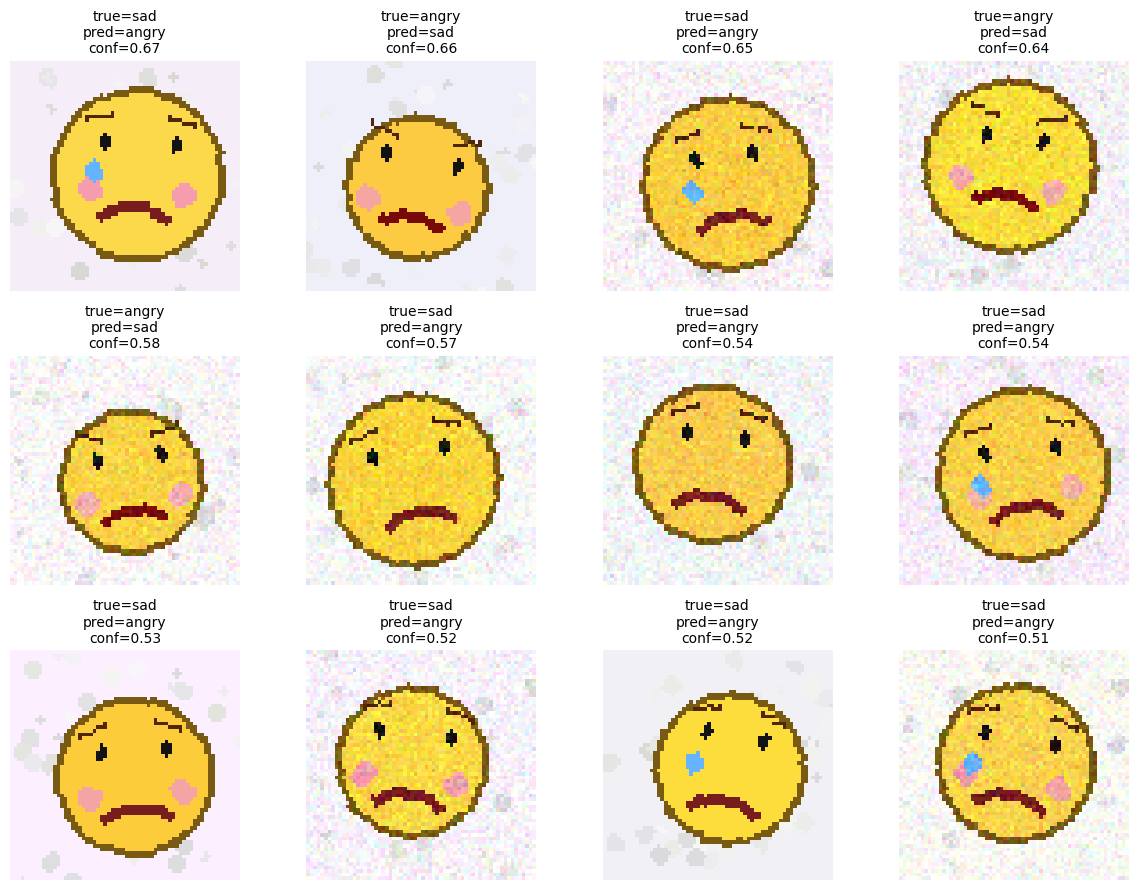

In [36]:
@torch.no_grad()
def collect_predictions_with_images(model, dataset, device, max_items=None):
    model.eval()
    items = []
    total = len(dataset) if max_items is None else min(len(dataset), max_items)

    for idx in range(total):
        image, label = dataset[idx]
        outputs = model(image.to(device).unsqueeze(0))
        prob = torch.softmax(outputs, dim=1).squeeze(0).cpu()
        pred = outputs.argmax(dim=1).item()

        items.append({
            "image": image,
            "label": label,
            "pred": pred,
            "confidence": float(prob[pred].item()),
        })
    return items

test_items = collect_predictions_with_images(baseline_model, test_dataset, device)
mistakes = [item for item in test_items if item["pred"] != item["label"]]
mistakes = sorted(mistakes, key=lambda x: x["confidence"], reverse=True)

print(f"Number of mistakes: {len(mistakes)} / {len(test_items)}")

n_show = min(12, len(mistakes))
if n_show > 0:
    cols = 4
    rows = math.ceil(n_show / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax in axes.ravel():
        ax.axis("off")

    for i in range(n_show):
        item = mistakes[i]
        img = denormalize(item["image"])
        ax = axes.ravel()[i]
        ax.imshow(img)
        ax.set_title(
            f"true={CLASS_NAMES[item['label']]}\npred={CLASS_NAMES[item['pred']]}\nconf={item['confidence']:.2f}",
            fontsize=10
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Great! No mistakes found in the displayed set.")

*تحلیل کیفی که شما از نتایج مشاهده کردید:*


Due to the similiarity between the mouths and the fact that the angry and sad emojis only differ in their eyebrows, in cases like these where the eyebrows are a little less curved downwards, the are predicted as angry.

## بخش ۱۱ — مشاهده‌ی feature mapها

### صورت سؤال
برای یکی از تصاویر تست:
1. خروجی اولین بلوک کانولوشنی را استخراج کنید.
2. چند feature map را نمایش دهید.
3. توضیح دهید که این feature mapها احتمالاً چه نوع الگوهایی را شکار می‌کنند.

### خروجی مورد انتظار
- تصویر ورودی
- چند feature map

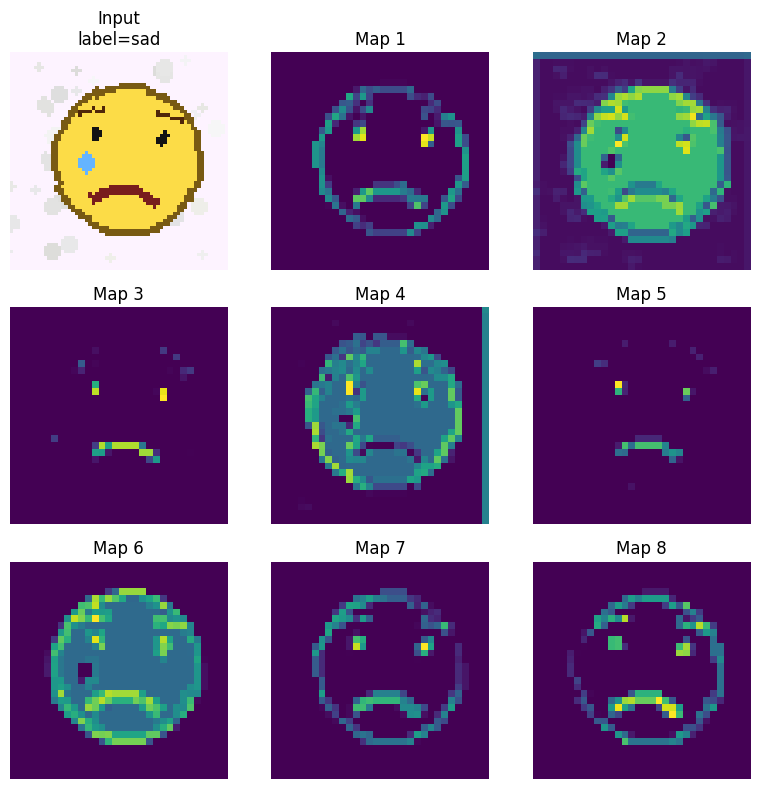

In [37]:
@torch.no_grad()
def show_feature_maps(model, dataset, sample_idx=0, n_maps=8):
    model.eval()
    image, label = dataset[sample_idx]
    x = image.unsqueeze(0).to(device)

    first_block = model.block1
    fmap = first_block(x).squeeze(0).cpu()

    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    axes = axes.ravel()

    axes[0].imshow(denormalize(image))
    axes[0].set_title(f"Input\nlabel={CLASS_NAMES[label]}")
    axes[0].axis("off")

    for i in range(1, min(n_maps + 1, 9)):
        axes[i].imshow(fmap[i - 1], cmap="viridis")
        axes[i].set_title(f"Map {i}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

show_feature_maps(baseline_model, test_dataset, sample_idx=3, n_maps=8)

Due to the fact that the yellow and green areas are the ones the channel paid the most attention to, we can conclude that forexample the 3rd channel is finding the eyes and the mouth and the 8th channel might be considering the right edges more and so on.

## بخش ۱۲ — مدل بهبود‌یافته

### صورت سؤال
اکنون یک مدل بهتر طراحی کنید که نسبت به مدل پایه، **پایدارتر** و **قابل‌تعمیم‌تر** باشد.

### پیشنهادها
- استفاده از `BatchNorm`
- استفاده از `AdaptiveAvgPool2d`
- استفاده از dropout بیشتر
- عمیق‌تر کردن مدل
- استفاده از optimizer و weight decay مناسب

### کارهای لازم
1. مدل جدید را پیاده‌سازی کنید.
2. آن را آموزش دهید.
3. عملکردش را با مدل پایه مقایسه کنید.

### خروجی مورد انتظار
- تعریف مدل جدید
- لاگ آموزش
- مقایسه‌ی metricها

In [57]:
class BetterCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
            )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) 
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.block5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  
        )
       
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.6), 
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.flatten(x)
        x = self.fc(x)

        return x

better_model = BetterCNN().to(device)
print(better_model)
print(f"Trainable params: {count_trainable_params(better_model):,}")

BetterCNN(
  (block1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (block3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): R

Epoch 01 | train_loss=1.7946 train_acc=0.2974 | val_loss=1.4883 val_acc=0.5508
Epoch 02 | train_loss=1.2223 train_acc=0.5669 | val_loss=0.8337 val_acc=0.7188
Epoch 03 | train_loss=0.8426 train_acc=0.7280 | val_loss=0.5043 val_acc=0.8535
Epoch 04 | train_loss=0.5827 train_acc=0.8149 | val_loss=0.2790 val_acc=0.9277
Epoch 05 | train_loss=0.4453 train_acc=0.8467 | val_loss=0.2696 val_acc=0.8809
Epoch 06 | train_loss=0.3604 train_acc=0.8794 | val_loss=0.1544 val_acc=0.9570
Epoch 07 | train_loss=0.3179 train_acc=0.8853 | val_loss=0.1272 val_acc=0.9668
Epoch 08 | train_loss=0.2462 train_acc=0.9160 | val_loss=0.1339 val_acc=0.9629
Epoch 09 | train_loss=0.2091 train_acc=0.9312 | val_loss=0.1028 val_acc=0.9707
Epoch 10 | train_loss=0.1767 train_acc=0.9468 | val_loss=0.0895 val_acc=0.9805
Epoch 11 | train_loss=0.1569 train_acc=0.9536 | val_loss=0.0657 val_acc=0.9883
Epoch 12 | train_loss=0.1388 train_acc=0.9609 | val_loss=0.0560 val_acc=0.9902
Epoch 13 | train_loss=0.1257 train_acc=0.9702 | val_

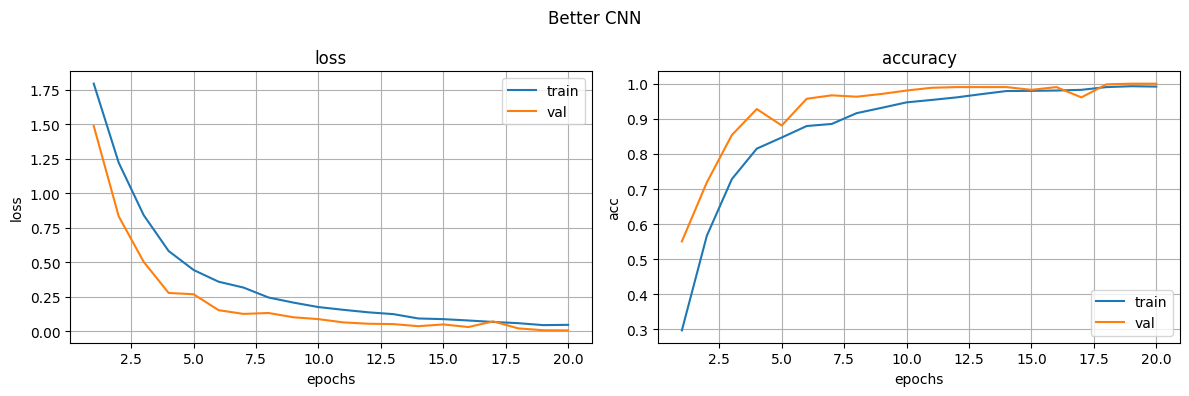

In [58]:
better_model = BetterCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(better_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=1, factor=0.5)

better_history = fit_model(
    better_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20,
    patience=4,
    scheduler=scheduler
)

plot_history(better_history, title_prefix="Better CNN")

,model,accuracy,precision_macro,recall_macro,f1_macro,params
0,BaselineCNN,0.982812,0.983218,0.982215,0.982298,1074215
1,BetterCNN,1.000000,1.000000,1.000000,1.000000,2234183


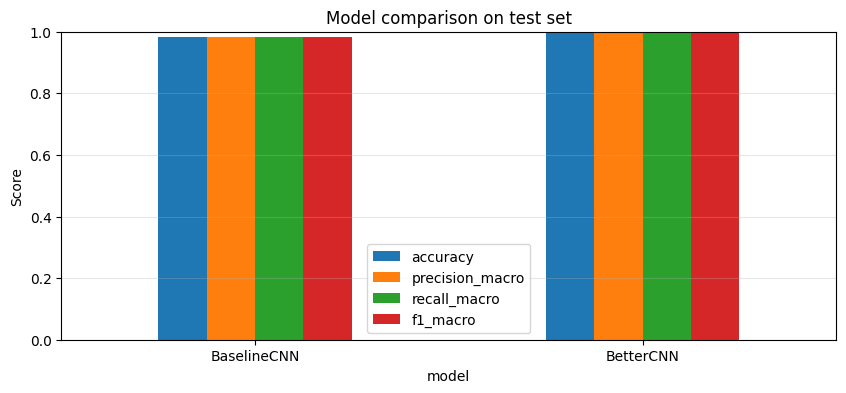

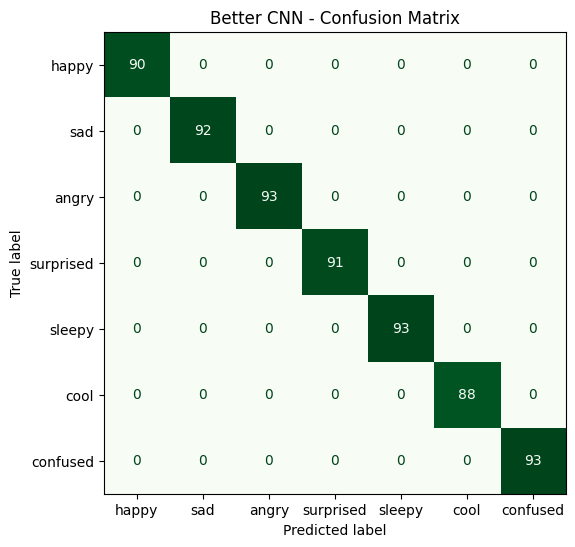

In [59]:
better_probs, better_preds, test_targets = predict_loader(better_model, test_loader, device)
better_acc = accuracy_score(test_targets, better_preds)
better_prec, better_rec, better_f1, _ = precision_recall_fscore_support(test_targets, better_preds, average='macro')

comparison_df = pd.DataFrame([
    {
        "model": "BaselineCNN",
        "accuracy": baseline_acc,
        "precision_macro": baseline_prec,
        "recall_macro": baseline_rec,
        "f1_macro": baseline_f1,
        "params": count_trainable_params(baseline_model),
    },
    {
        "model": "BetterCNN",
        "accuracy": better_acc,
        "precision_macro": better_prec,
        "recall_macro": better_rec,
        "f1_macro": better_f1,
        "params": count_trainable_params(better_model),
    },
])

display(comparison_df)

comparison_df.set_index("model")[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].plot(
    kind="bar", figsize=(10, 4)
)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Model comparison on test set")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.show()

cm_better = confusion_matrix(test_targets, better_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_better, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Greens", values_format="d", colorbar=False)
plt.title("Better CNN - Confusion Matrix")
plt.show()

## بخش ۱۳ — جمع‌بندی و پرسش‌های تحلیلی

### صورت سؤال
به پرسش‌های زیر پاسخ دهید:

1. آیا augmentation باعث بهتر شدن عملکرد مدل شد؟ چرا؟
2. کدام کلاس‌ها بیشتر با هم اشتباه شدند؟ دلیل بصری آن چیست؟
3. بین مدل پایه و مدل بهتر، کدام تغییرات بیشترین اثر را داشتند؟
4. آیا افزایش تعداد پارامترها همیشه به بهبود نتیجه منجر شد؟
5. اگر بخواهید این پروژه را سخت‌تر کنید، چه تغییری می‌دهید؟

### چند ایده برای بخش امتیازی
- ساخت یک **harder test set** با occlusion شدیدتر
- مقایسه‌ی optimizerهای `Adam` و `RMSprop`
- اضافه کردن **label smoothing**
- پیاده‌سازی **Grad-CAM** برای توضیح تصمیم مدل
- تبدیل مسئله از 5 کلاس به 7 کلاس با اضافه کردن `cool` و `confused`



1. Yes, by having more data we are allowing the model to learn the patterns more correctly rather than overfitting on the data at the beginning.

2. Angry and sad with eachother and happy and sleepy with eachother - due to the fact that the difference between the first two was only their eyebrows and the second two their mouths. the ones with eyebrows or mouths in between often created confusion.

3. Using more convolution layers and also using a lr scheduler and weight decay all helped with it so that it would learn more features and also not overfit or have zigzag and weird patterns.

4. No - they can cause overfitting which would damage the generalization.

5. By adding more faces which are more similiar to eachother and also by adding images of differnct sizes or by adding noisy wrong labels.

Epoch 01 | train_loss=1.7032 train_acc=0.4663 | val_loss=0.9967 val_acc=0.8574
Epoch 02 | train_loss=0.7275 train_acc=0.7559 | val_loss=0.5501 val_acc=0.7773
Epoch 03 | train_loss=0.4691 train_acc=0.8281 | val_loss=0.3911 val_acc=0.8164
Epoch 04 | train_loss=0.3840 train_acc=0.8418 | val_loss=0.1811 val_acc=0.9609
Epoch 05 | train_loss=0.3070 train_acc=0.8833 | val_loss=0.1551 val_acc=0.9570
Epoch 06 | train_loss=0.2576 train_acc=0.8979 | val_loss=0.1722 val_acc=0.8906
Epoch 07 | train_loss=0.2217 train_acc=0.9180 | val_loss=0.1534 val_acc=0.9258
Epoch 08 | train_loss=0.2201 train_acc=0.9238 | val_loss=0.0886 val_acc=0.9746
Epoch 09 | train_loss=0.1899 train_acc=0.9292 | val_loss=0.2214 val_acc=0.8945
Epoch 10 | train_loss=0.1461 train_acc=0.9517 | val_loss=0.0865 val_acc=0.9668
Epoch 11 | train_loss=0.1485 train_acc=0.9468 | val_loss=0.0805 val_acc=0.9688
Epoch 12 | train_loss=0.1110 train_acc=0.9663 | val_loss=0.0896 val_acc=0.9668
Epoch 13 | train_loss=0.1038 train_acc=0.9736 | val_

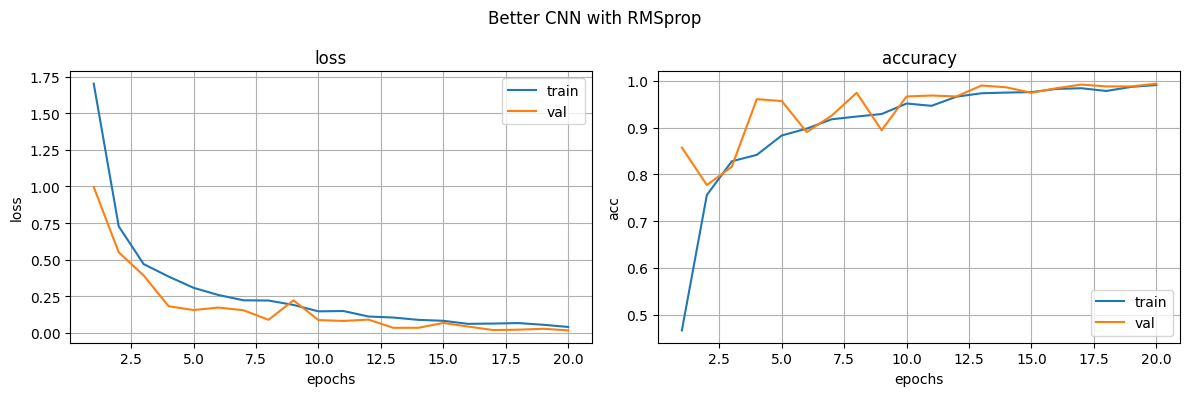

In [60]:
better_model = BetterCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.RMSprop(better_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=1, factor=0.5)

better_history = fit_model(
    better_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20,
    patience=4,
    scheduler=scheduler
)

plot_history(better_history, title_prefix="Better CNN with RMSprop")

RMSprop doesn't use the firstmoment and therefore, it has a very zigzag path in comparison to the adam opimizer.